# Corporate Event Extraction from SEC 8-K Filings at Scale

**Chapter 23: Knowledge Graphs for Financial AI** | Section 23.6

**Docker image**: `ml4t-gpu`

> **Neo4j + GPU required**: This notebook needs a Neo4j graph database and GPU
> for NER/embedding models:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t-gpu python 23_knowledge_graphs/08_8k_event_extraction.py
> ```


This notebook demonstrates large-scale event extraction from SEC 8-K filings,
using batch LLM inference and deterministic schema normalization to construct
a corporate event knowledge graph.

**Learning Objectives**:
- Extract structured event quadruples (subject, relation, object, timestamp) from 8-K filings
- Validate and normalize extracted events against an explicit schema
- Load event graphs into Neo4j using efficient UNWIND batch operations
- Write temporal Cypher queries over corporate event data

**Book Reference**: Chapter 23, Section 23.6 (Temporal Integrity and Leakage-Safe Evaluation)

**Prerequisites**: Familiarity with `02_supply_chain_kg_construction` notebook;
requires Neo4j for graph loading and a GPU-backed Qwen model for extraction.

In [1]:
"""Corporate Event Extraction from SEC 8-K Filings at Scale."""

from __future__ import annotations

import hashlib
import json
import logging
import math
import os
import re
import textwrap
import time
import warnings
from dataclasses import dataclass, field
from datetime import UTC, date, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import torch

from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Production defaults - Papermill overrides for testing.
# The staged SP100 8-K corpus ships with ~1,249 filings × 101 SP100 companies × 2020-2025.
# The notebook narrative is calibrated to a 50-filing demo for tractability.
# Set MAX_FILINGS=0 to process the entire staged corpus (~10x runtime).
MAX_FILINGS = 50

# LLM model - local HuggingFace transformers checkpoint loaded onto CUDA.
#   Default: Qwen/Qwen2.5-7B-Instruct (fp16 ~14 GB, fits 24 GB GPU comfortably).
#   Alt:     Qwen/Qwen3-8B            (fp16 ~16 GB; native thinking mode).
# Set ENABLE_THINKING=True only with a Qwen3 family model.
# Bump MAX_NEW_TOKENS to ~2048 when ENABLE_THINKING=True (CoT eats tokens).
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
MODEL_REVISION = "a09a35458c702b33eeacc393d103063234e8bc28"
ENABLE_THINKING = False
MAX_NEW_TOKENS = 512

# Batch size for LLM inference
BATCH_SIZE = 4  # Smaller than supply chain due to longer prompts

# Greedy decoding pins outputs run-to-run. With sampling on (do_sample=True) the
# validation %, correction counts, and event totals drift between runs even at
# low temperature - see Ch23 diagnosis methodology.
DO_SAMPLE = False
SEED = 42

In [3]:
set_global_seeds(SEED)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

## Infrastructure Detection

Detect available infrastructure: GPU for Qwen2.5-7B, Neo4j for graph storage.

In [4]:
# GPU-backed production extraction is mandatory.
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for the Qwen event-extraction run.")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA GeForce RTX 3090
Memory: 25.3 GB


In [5]:
# Neo4j connection settings (from environment or defaults)
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

from neo4j import GraphDatabase

NEO4J_DRIVER = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
NEO4J_DRIVER.verify_connectivity()
print(f"Neo4j connected: {NEO4J_URI}")

Neo4j connected: bolt://neo4j:7687


In [6]:
# Load only the pinned local checkpoint. Production must not fetch from the network.
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.utils import logging as transformers_logging

transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()

print(f"Loading local checkpoint {MODEL_NAME}...")
LLM_TOKENIZER = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    padding_side="left",
    local_files_only=True,
)
if LLM_TOKENIZER.pad_token is None:
    LLM_TOKENIZER.pad_token = LLM_TOKENIZER.eos_token
LLM_MODEL = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    dtype=torch.float16,
    device_map="cuda",
    local_files_only=True,
)
if LLM_MODEL.config._name_or_path != MODEL_NAME:
    raise RuntimeError(
        f"Loaded model identity {LLM_MODEL.config._name_or_path!r} != {MODEL_NAME!r}"
    )
parameter_devices = {parameter.device.type for parameter in LLM_MODEL.parameters()}
if parameter_devices != {"cuda"}:
    raise RuntimeError(f"Qwen parameters are not exclusively on CUDA: {parameter_devices}")
if not DO_SAMPLE:
    LLM_MODEL.generation_config.temperature = None
    LLM_MODEL.generation_config.top_p = None
    LLM_MODEL.generation_config.top_k = None
print(f"LLM loaded on {next(LLM_MODEL.parameters()).device}; batch size: {BATCH_SIZE}")

Loading local checkpoint Qwen/Qwen2.5-7B-Instruct...


LLM loaded on cuda:0; batch size: 4


## 1. Configuration

Event schema and extraction parameters.

In [7]:
# Event types from SEC 8-K item numbers
EVENT_TYPES = {
    "1.01": "Material Agreement",
    "2.01": "Acquisition/Disposition",
    "5.02": "Executive Change",
    "7.01": "Regulation FD Disclosure",
    "8.01": "Other Events",
}

# Node types in event graph
NODE_TYPES = ["Company", "Person", "Event", "Amount"]

RELATIONSHIP_TYPES = ["ANNOUNCED", "APPOINTED", "ACQUIRED", "VALUED_AT"]
META_TYPES = [
    "EXECUTIVE_CHANGE",
    "ACQUISITION",
    "STRATEGIC_PARTNERSHIP",
    "DISCLOSURE",
]

# CheckRules validation settings
MAX_ENTITY_WORDS = 5
VALID_RELATIONS = set(RELATIONSHIP_TYPES)

## 2. 8-K Filing Data

Load the immutable staged 8-K corpus. Missing input stops the run.

In [8]:
def detect_item_number(text: str) -> str:
    """Infer the primary 8-K item number from the filing text."""
    for item_num in EVENT_TYPES:
        if f"Item {item_num}" in text:
            return item_num
    return "8.01"

### Immutable Input Identity

Hash the staged corpus before selecting the fixed 50-filing extraction cohort.

In [9]:
def sha256_file(path: Path) -> str:
    """Return the SHA-256 digest of a local file."""
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

In [10]:
data_root = Path(os.getenv("ML4T_DATA_PATH", "data"))
source_path = data_root / "equities/fundamentals/8k/sp100/reference/all_8k_filings.parquet"
if not source_path.is_file():
    raise FileNotFoundError(f"Staged 8-K corpus not found: {source_path}")
SOURCE_SHA256 = sha256_file(source_path)
filings_df = pl.read_parquet(source_path).sort(["filing_date", "symbol", "accession_no"])
SOURCE_ROWS = filings_df.height
required_columns = {"accession_no", "cik", "filing_date", "symbol", "text"}
missing_columns = required_columns - set(filings_df.columns)
if missing_columns:
    raise ValueError(f"Staged 8-K corpus is missing required fields: {sorted(missing_columns)}")
null_counts = filings_df.select(
    pl.col(column).is_null().sum().alias(column) for column in sorted(required_columns)
).row(0, named=True)
if any(null_counts.values()):
    raise ValueError(f"Staged 8-K corpus contains null required fields: {null_counts}")
accession_conflicts = (
    filings_df.group_by("accession_no")
    .agg(
        pl.col("cik").n_unique().alias("ciks"),
        pl.col("filing_date").n_unique().alias("filing_dates"),
        pl.col("text").n_unique().alias("texts"),
    )
    .filter((pl.col("ciks") > 1) | (pl.col("filing_dates") > 1) | (pl.col("texts") > 1))
)
if accession_conflicts.height:
    raise ValueError("Duplicate accessions disagree on filing identity or text.")
filings_df = filings_df.unique(subset="accession_no", keep="first", maintain_order=True)
UNIQUE_SOURCE_FILINGS = filings_df.height

In [11]:
filings_df = filings_df.with_columns(
    pl.col("text").map_elements(detect_item_number, return_dtype=pl.Utf8).alias("item")
)
if MAX_FILINGS > 0 and UNIQUE_SOURCE_FILINGS > MAX_FILINGS:
    stride = max(1, math.ceil(UNIQUE_SOURCE_FILINGS / MAX_FILINGS))
    filings_df = filings_df.gather_every(stride).head(MAX_FILINGS)
filing_data = filings_df.to_dicts()
if MAX_FILINGS > 0 and len(filing_data) != min(MAX_FILINGS, UNIQUE_SOURCE_FILINGS):
    raise RuntimeError("Deterministic filing selection did not produce the requested count.")
EXTRACTION_TIME = datetime.now(UTC).replace(microsecond=0).isoformat()
EXTRACTION_DATE = EXTRACTION_TIME[:10]
selected_accessions = [row["accession_no"] for row in filing_data]
SELECTED_ACCESSIONS_SHA256 = hashlib.sha256("\n".join(selected_accessions).encode()).hexdigest()
run_identity = {
    "source_sha256": SOURCE_SHA256,
    "selected_accessions_sha256": SELECTED_ACCESSIONS_SHA256,
    "model": MODEL_NAME,
    "model_revision": MODEL_REVISION,
    "do_sample": DO_SAMPLE,
    "max_new_tokens": MAX_NEW_TOKENS,
}
RUN_ID = hashlib.sha256(json.dumps(run_identity, sort_keys=True).encode()).hexdigest()[:24]
print(f"Staged source: {SOURCE_ROWS:,} filings; SHA-256 {SOURCE_SHA256[:12]}...")
print(f"Unique SEC accessions: {UNIQUE_SOURCE_FILINGS:,}")
print(f"Deterministic extraction cohort: {len(filing_data)} filings")
print(f"Selected accessions SHA-256: {SELECTED_ACCESSIONS_SHA256}")
print(f"Run ID: {RUN_ID}")

Staged source: 1,249 filings; SHA-256 bcee2f334c23...
Unique SEC accessions: 1,237
Deterministic extraction cohort: 50 filings
Selected accessions SHA-256: dcdda2465102aa27665ed9fd942bb59bf32de72c0e3d321099d538b931649887
Run ID: a121f0027b7e154a620ffe9d


## 3. Event Extraction Schema

Define the event quadruple structure.

### EventQuadruple

Each extracted event follows the FinDKG quadruple format: (subject, relation,
object, timestamp) plus optional metadata. This mirrors the temporal knowledge
graph representation used in Section 23.6.

In [12]:
@dataclass
class EventQuadruple:
    """Event extraction result following FinDKG quadruple format."""

    event_id: str
    subject: str
    relation: str
    object: str
    timestamp: str
    public_date: str | None = None
    extraction_date: str | None = None
    meta_entity: str | None = None
    source_cik: str | None = None
    source_accession_no: str | None = None

    def to_dict(self) -> dict:
        return {
            "event_id": self.event_id,
            "subject": self.subject,
            "relation": self.relation,
            "object": self.object,
            "timestamp": self.timestamp,
            "public_date": self.public_date,
            "extraction_date": self.extraction_date,
            "meta_entity": self.meta_entity,
            "source_cik": self.source_cik,
            "source_accession_no": self.source_accession_no,
        }

### CheckRulesResult

Container for the CheckRules validation outcome, capturing
which rules were violated and how to correct them.

In [13]:
@dataclass
class CheckRulesResult:
    """Result of CheckRules validation."""

    is_valid: bool
    violations: list[str] = field(default_factory=list)
    suggestions: list[str] = field(default_factory=list)

In [14]:
@dataclass
class ExtractionResult:
    """Conserved extraction outcome for one filing."""

    accession_no: str
    status: str
    events: list[EventQuadruple] = field(default_factory=list)
    error: str | None = None

## 4. LLM Event Extraction

Extract events using Qwen2.5-7B-Instruct with structured prompting.

In [15]:
EVENT_PROMPT_HEADER = """You are an expert financial analyst extracting corporate events from SEC 8-K filings.

Extract structured events as JSON following this schema:
{
  "events": [
    {
      "subject": "COMPANY NAME IN UPPERCASE",
      "relation": "RELATION_TYPE",
      "object": "TARGET NAME IN UPPERCASE",
      "timestamp": "YYYY-MM-DD",
      "meta_entity": "EVENT_CATEGORY"
    }
  ]
}
"""

In [16]:
EVENT_PROMPT_RULES = """RULES (CheckRules - follow exactly):
1. Entity names MUST be uppercase (e.g., "APPLE INC" not "Apple Inc.")
2. Entity names MUST be <= 5 words
3. NO leading articles (THE, A, AN)
4. Valid relations ONLY: ANNOUNCED, APPOINTED, ACQUIRED, VALUED_AT
5. Valid meta_entity: EXECUTIVE_CHANGE, ACQUISITION, STRATEGIC_PARTNERSHIP, DISCLOSURE
6. Dates in YYYY-MM-DD format

EVENT EXTRACTION EXAMPLES:

For executive appointments (Item 5.02):
- Subject: Company name
- Relation: APPOINTED
- Object: Person name
- meta_entity: EXECUTIVE_CHANGE

For acquisitions (Item 2.01):
- Subject: Acquiring company
- Relation: ACQUIRED
- Object: Target company
- meta_entity: ACQUISITION
- If price mentioned, add second event with VALUED_AT

For strategic announcements (Item 8.01):
- Subject: Company name
- Relation: ANNOUNCED
- Object: Brief description (<= 5 words)
- meta_entity: STRATEGIC_PARTNERSHIP or DISCLOSURE

Extract ALL events from the text. Be precise with dates - use the specific date mentioned, not the filing date.
"""
EVENT_EXTRACTION_PROMPT = f"{EVENT_PROMPT_HEADER}\n{EVENT_PROMPT_RULES}"

### Single-Filing Extraction

Extract events from one 8-K filing using Qwen2.5-7B-Instruct.

In [17]:
def build_event_prompt(filing: dict, max_chars: int | None = None) -> str:
    """Create the user prompt for event extraction."""
    filing_text = filing["text"].strip()
    if max_chars is not None:
        filing_text = filing_text[:max_chars]
    messages = [
        {"role": "system", "content": EVENT_EXTRACTION_PROMPT},
        {
            "role": "user",
            "content": f"""Company: {filing["company_name"]} ({filing["symbol"]})
Filing Date: {filing["filing_date"]}
Item: {filing.get("item", "8.01")} ({EVENT_TYPES.get(filing.get("item", "8.01"), "Other Events")})

Text:
{filing_text}

Extract all events as JSON:""",
        },
    ]
    template_options = {}
    if "Qwen3" in MODEL_NAME:
        template_options["enable_thinking"] = ENABLE_THINKING
    return LLM_TOKENIZER.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        **template_options,
    )

### Response Parser

Normalize model output into `EventQuadruple` objects and raise if the
model response is not valid structured JSON.

In [18]:
def extract_json_events(response: str) -> list[dict]:
    """Extract the event list from a model response."""
    clean = re.sub(r"<think>.*?</think>", "", response, flags=re.DOTALL).strip()
    fenced = re.search(r"```json\s*(.*?)\s*```", clean, re.DOTALL)
    unfenced = re.search(r"\{.*\}", clean, re.DOTALL)
    if fenced is None and unfenced is None:
        raise ValueError("response contains no JSON object")
    document = fenced.group(1) if fenced else unfenced.group(0)
    data = json.loads(document)
    raw_events = data.get("events")
    if not isinstance(raw_events, list):
        raise ValueError("JSON field 'events' must be a list")
    return raw_events

In [19]:
def parse_event_response(response: str, filing: dict) -> list[EventQuadruple]:
    """Parse an LLM response while preserving the filing-to-output boundary."""
    key = filing["accession_no"]
    try:
        parsed = []
        for position, event in enumerate(extract_json_events(response)):
            if not isinstance(event, dict):
                raise ValueError(f"event {position} is not an object")
            required = ("subject", "relation", "object", "timestamp", "meta_entity")
            if any(not isinstance(event.get(name), str) for name in required):
                raise ValueError(f"event {position} has missing or non-string fields")
            identity = "|".join(
                [
                    key,
                    str(position),
                    event["subject"],
                    event["relation"],
                    event["object"],
                    event["timestamp"],
                ]
            )
            parsed.append(
                EventQuadruple(
                    event_id=hashlib.sha256(identity.encode()).hexdigest()[:24],
                    subject=event["subject"].strip(),
                    relation=event["relation"].strip(),
                    object=event["object"].strip(),
                    timestamp=event["timestamp"].strip(),
                    public_date=str(filing["filing_date"]),
                    extraction_date=EXTRACTION_DATE,
                    meta_entity=event["meta_entity"].strip(),
                    source_cik=filing["cik"],
                    source_accession_no=key,
                )
            )
        return parsed
    except (json.JSONDecodeError, AttributeError, TypeError, ValueError) as exc:
        raise ValueError(f"Could not parse extracted events for {key}: {exc}") from exc

### Single-Filing Extraction

Run one filing through the local LLM and parse the generated JSON output.

In [20]:
def extract_events_llm(filing: dict) -> list[EventQuadruple]:
    """Extract events using Qwen2.5-7B-Instruct."""
    text = build_event_prompt(filing)
    inputs = LLM_TOKENIZER([text], return_tensors="pt").to("cuda")
    options = {
        "max_new_tokens": MAX_NEW_TOKENS,
        "do_sample": DO_SAMPLE,
        "pad_token_id": LLM_TOKENIZER.eos_token_id,
    }
    if DO_SAMPLE:
        options["temperature"] = 0.1
    with torch.inference_mode():
        outputs = LLM_MODEL.generate(**inputs, **options)
    response = LLM_TOKENIZER.decode(
        outputs[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True
    )
    events = parse_event_response(response, filing)
    if not events:
        raise ValueError(
            f"No structured events were extracted for {filing['cik']}_{filing['filing_date']}"
        )
    return events

### Batch Extraction

Process multiple filings in a single forward pass to amortize per-token GPU
overhead across the batch. This notebook runs with `BATCH_SIZE=4` and does
not benchmark sequential extraction.

In [21]:
def extract_events_batch(filings: list[dict]) -> list[ExtractionResult]:
    """Extract events with one explicit outcome for every input filing."""
    prompts = [build_event_prompt(filing, max_chars=4000) for filing in filings]
    model_inputs = LLM_TOKENIZER(
        prompts, return_tensors="pt", padding=True, truncation=True, max_length=4096
    ).to("cuda")
    generation_options = {
        "max_new_tokens": MAX_NEW_TOKENS,
        "do_sample": DO_SAMPLE,
        "pad_token_id": LLM_TOKENIZER.pad_token_id,
    }
    if DO_SAMPLE:
        generation_options["temperature"] = 0.1
    with torch.inference_mode():
        generated_ids = LLM_MODEL.generate(**model_inputs, **generation_options)
    results = []
    for i, (input_ids, output_ids) in enumerate(
        zip(model_inputs.input_ids, generated_ids, strict=False)
    ):
        generated = output_ids[len(input_ids) :]
        response = LLM_TOKENIZER.decode(generated, skip_special_tokens=True)
        try:
            events = parse_event_response(response, filings[i])
            status = "parsed" if events else "zero_events"
            results.append(ExtractionResult(filings[i]["accession_no"], status, events))
        except (ValueError, KeyError) as exc:
            results.append(
                ExtractionResult(filings[i]["accession_no"], "parse_failure", error=str(exc))
            )
    return results

### Batch Iterator

Chunk filings into GPU-friendly groups before sending them to the model.

In [22]:
def batched(iterable, n: int):
    """Yield successive n-sized chunks from iterable."""
    items = list(iterable)
    for i in range(0, len(items), n):
        yield items[i : i + n]

## 5. CheckRules Validation

Validate extractions against schema rules.

In [23]:
def check_rules(event: EventQuadruple) -> CheckRulesResult:
    """Validate one extracted event against the declared graph schema."""
    violations = []
    suggestions = []

    if not event.subject:
        violations.append("Subject is empty")
    if not event.object:
        violations.append("Object is empty")
    if len(event.subject.split()) > MAX_ENTITY_WORDS:
        violations.append(f"Subject '{event.subject}' exceeds {MAX_ENTITY_WORDS} words")
        suggestions.append("Manual review required for long subject")

    if event.subject != event.subject.upper() or event.subject.startswith(("THE ", "A ", "AN ")):
        violations.append(f"Subject '{event.subject}' not properly formatted")
        suggestions.append(f"Normalize to: '{event.subject.upper()}'")

    # Check object
    if len(event.object.split()) > MAX_ENTITY_WORDS:
        violations.append(f"Object '{event.object}' exceeds {MAX_ENTITY_WORDS} words")
        suggestions.append("Manual review required for long object")

    if event.object != event.object.upper() or event.object.startswith(("THE ", "A ", "AN ")):
        violations.append(f"Object '{event.object}' not properly formatted")
        suggestions.append(f"Normalize to: '{event.object.upper()}'")

    # Check relation
    if event.relation not in VALID_RELATIONS:
        violations.append(f"Relation '{event.relation}' not in valid set")
        suggestions.append(f"Valid relations: {sorted(VALID_RELATIONS)}")
    if event.meta_entity not in META_TYPES:
        violations.append(f"Meta entity '{event.meta_entity}' not in valid set")
    try:
        date.fromisoformat(event.timestamp)
    except ValueError:
        violations.append(f"Timestamp '{event.timestamp}' is not an ISO date")

    return CheckRulesResult(
        is_valid=len(violations) == 0, violations=violations, suggestions=suggestions
    )

## 6. Deterministic Schema Normalization

Normalize formatting errors, then route unresolved schema failures for review.

### Validator

The validator reports schema violations without judging whether an extracted
fact is supported by the filing text.

In [24]:
def validate_event(event: EventQuadruple) -> CheckRulesResult:
    """Identify schema violations."""
    return check_rules(event)

### Normalizer

The normalizer deterministically fixes formatting violations:
uppercasing and stripping leading articles.
It does not rewrite relations, dates, event categories, or semantic content.

In [25]:
def normalize_event(event: EventQuadruple) -> EventQuadruple:
    """Normalize entity formatting without changing event semantics."""
    corrected = EventQuadruple(
        event_id=event.event_id,
        subject=event.subject,
        relation=event.relation,
        object=event.object,
        timestamp=event.timestamp,
        public_date=event.public_date,
        extraction_date=event.extraction_date,
        meta_entity=event.meta_entity,
        source_cik=event.source_cik,
        source_accession_no=event.source_accession_no,
    )

    # Fix format violations
    corrected.subject = corrected.subject.upper()
    corrected.object = corrected.object.upper()

    # Remove articles
    for article in ["THE ", "A ", "AN "]:
        if corrected.subject.startswith(article):
            corrected.subject = corrected.subject[len(article) :]
        if corrected.object.startswith(article):
            corrected.object = corrected.object[len(article) :]

    return corrected

### Validation Boundary

Normalize once. Events that still fail are excluded from the graph and
retained in the unresolved collection for manual review.

In [26]:
def normalize_and_validate(
    events: list[EventQuadruple],
) -> tuple[list[EventQuadruple], list[EventQuadruple], dict[str, int]]:
    """Return accepted and unresolved events with conservation statistics."""
    stats = {"initial_valid": 0, "normalized_valid": 0, "normalized_events": 0}
    accepted = []
    unresolved = []
    for event in events:
        result = validate_event(event)
        if result.is_valid:
            stats["initial_valid"] += 1
            accepted.append(event)
            continue
        normalized = normalize_event(event)
        if normalized.to_dict() != event.to_dict():
            stats["normalized_events"] += 1
        final_result = validate_event(normalized)
        if final_result.is_valid:
            stats["normalized_valid"] += 1
            accepted.append(normalized)
        else:
            unresolved.append(normalized)
    if len(events) != len(accepted) + len(unresolved):
        raise RuntimeError("Event validation did not conserve extracted events.")
    return accepted, unresolved, stats

## 7. Run Batch Extraction Pipeline

In [27]:
print("=" * 60)
print("BATCH EVENT EXTRACTION")
print("=" * 60)

start_time = time.time()
all_events = []
extraction_results = []

for batch_idx, batch in enumerate(batched(filing_data, BATCH_SIZE)):
    batch_results = extract_events_batch(batch)
    extraction_results.extend(batch_results)
    batch_event_count = sum(len(result.events) for result in batch_results)
    all_events.extend(event for result in batch_results for event in result.events)
    print(f"Batch {batch_idx + 1}: {len(batch)} filings, {batch_event_count} events")

elapsed = time.time() - start_time
outcome_counts = {
    status: sum(result.status == status for result in extraction_results)
    for status in ("parsed", "zero_events", "parse_failure")
}
if len(extraction_results) != len(filing_data):
    raise RuntimeError("Filing extraction did not preserve positional accounting.")
print(f"\nExtraction completed in {elapsed:.1f}s")
print(f"Initial extraction: {len(all_events)} events")
print(f"Filing outcomes: {outcome_counts}")

# Apply deterministic schema normalization.
accepted_events, unresolved_events, validation_stats = normalize_and_validate(all_events)

print("\nSchema validation:")
print(f"  Initially valid: {validation_stats['initial_valid']}")
print(f"  Normalized events: {validation_stats['normalized_events']}")
print(f"  Valid after normalization: {validation_stats['normalized_valid']}")
print(f"  Unresolved for manual review: {len(unresolved_events)}")

BATCH EVENT EXTRACTION


Batch 1: 4 filings, 11 events


Batch 2: 4 filings, 4 events


Batch 3: 4 filings, 6 events


Batch 4: 4 filings, 5 events


...

Batch 9: 4 filings, 4 events


Batch 10: 4 filings, 4 events


Batch 11: 4 filings, 6 events


Batch 12: 4 filings, 5 events


Batch 13: 2 filings, 3 events

Extraction completed in 89.8s
Initial extraction: 72 events
Filing outcomes: {'parsed': 50, 'zero_events': 0, 'parse_failure': 0}

Schema validation:
  Initially valid: 58
  Normalized events: 5
  Valid after normalization: 3
  Unresolved for manual review: 11


**Interpretation**: Schema validation and semantic accuracy are different
questions. The deterministic normalizer repairs casing and leading articles.
Long entities, invalid relations, invalid dates, and invalid categories remain
unresolved and do not enter the graph. Confirming that an accepted event is
supported by the filing text requires a separate labeled audit.

## 8. Graph Statistics

In [28]:
# Analyze extracted events
companies = set()
persons = set()
acquisitions = []
appointments = []

for event in accepted_events:
    if event.relation == "ACQUIRED":
        acquisitions.append(event)
        companies.add(event.subject)
        companies.add(event.object)
    elif event.relation == "APPOINTED":
        appointments.append(event)
        companies.add(event.subject)
        persons.add(event.object)
    elif event.relation in {"ANNOUNCED", "VALUED_AT"}:
        companies.add(event.subject)

# Event type distribution
event_types = {}
for event in accepted_events:
    meta = event.meta_entity or "UNKNOWN"
    event_types[meta] = event_types.get(meta, 0) + 1

print("=" * 50)
print("8-K EVENT GRAPH STATISTICS")
print("=" * 50)
print(f"Schema-valid events:      {len(accepted_events)}")
print(f"Unresolved events:        {len(unresolved_events)}")
print(f"Unique companies:         {len(companies)}")
print(f"Unique persons:           {len(persons)}")
print(f"Acquisition events:       {len(acquisitions)}")
print(f"Appointment events:       {len(appointments)}")
print()
print("Event Type Distribution:")
for event_type, count in sorted(event_types.items()):
    print(f"  {event_type}: {count}")

8-K EVENT GRAPH STATISTICS
Schema-valid events:      61
Unresolved events:        11
Unique companies:         47
Unique persons:           8
Acquisition events:       7
Appointment events:       8

Event Type Distribution:
  ACQUISITION: 14
  DISCLOSURE: 38
  EXECUTIVE_CHANGE: 8
  STRATEGIC_PARTNERSHIP: 1


### Event Type Distribution

Visualize the mix of extracted event types and per-company event counts.

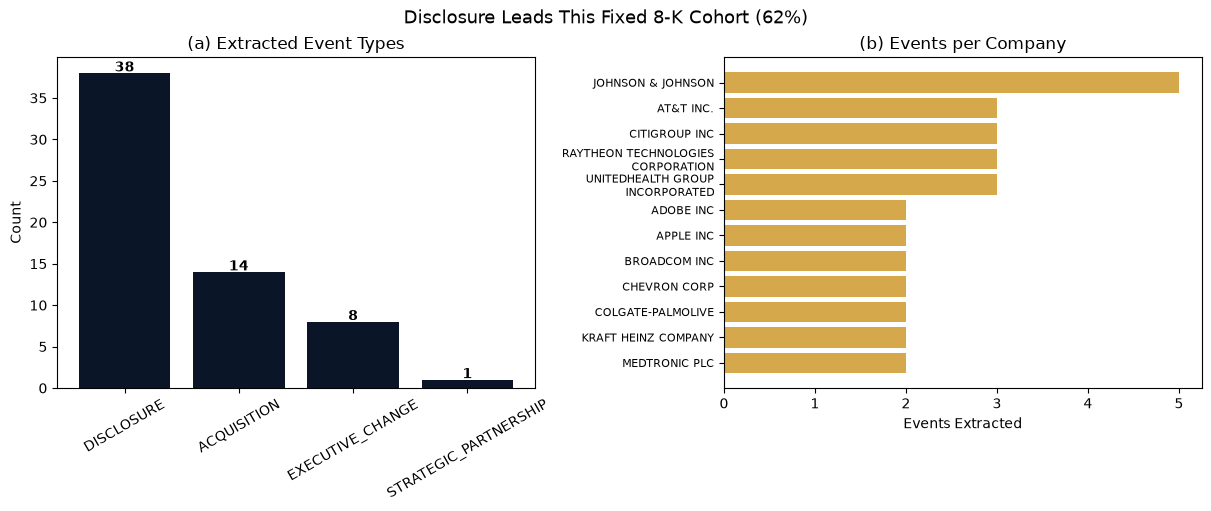

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

# Panel (a): Event type distribution
if event_types:
    types = list(event_types.keys())
    counts = list(event_types.values())
    axes[0].bar(types, counts, color=COLORS["blue"])
    axes[0].set_ylabel("Count")
    axes[0].set_title("(a) Extracted Event Types")
    axes[0].tick_params(axis="x", rotation=30)
    for i, (t, c) in enumerate(zip(types, counts)):
        axes[0].text(i, c + 0.2, str(c), ha="center", fontweight="bold")

# Panel (b): Events per company
if companies:
    company_counts = {}
    for event in accepted_events:
        company_counts[event.subject] = company_counts.get(event.subject, 0) + 1
    sorted_cos = sorted(company_counts.items(), key=lambda item: (-item[1], item[0]))[:12]
    names = [textwrap.fill(name, width=22) for name, _ in sorted_cos]
    cnts = [c for _, c in sorted_cos]
    axes[1].barh(range(len(names)), cnts, color=COLORS["amber"])
    axes[1].set_yticks(range(len(names)))
    axes[1].set_yticklabels(names, fontsize=8)
    axes[1].set_xlabel("Events Extracted")
    axes[1].set_title("(b) Events per Company")
    axes[1].invert_yaxis()

dominant_type, dominant_count = max(event_types.items(), key=lambda item: (item[1], item[0]))
dominant_label = dominant_type.replace("_", " ").title()
dominant_share = dominant_count / len(accepted_events)
fig.suptitle(
    f"{dominant_label} Leads This Fixed 8-K Cohort ({dominant_share:.0%})",
    fontsize=13,
)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
    fig.show()

**Finding**: The chart describes this fixed filing sample, not the population
of 8-K events. Category totals depend on both the sampled filings and the
model extraction. The unresolved count above is the correct boundary for
manual review; schema-valid output is not labeled semantic ground truth.

## 9. Neo4j Loading

Load events to Neo4j with a real database connection.

### Batch Neo4j Loader

Use Cypher `UNWIND` to load events in batches of 500 (configurable).
This is orders of magnitude faster than individual `CREATE` statements
because it amortizes network round-trips and transaction overhead.

In [30]:
def load_event_batches(
    session,
    events: list[EventQuadruple],
    batch_size: int,
    query: str,
    mapper,
) -> None:
    """Load one relation type with UNWIND and fail on any write error."""
    for batch in batched(events, batch_size):
        session.run(query, batch=[mapper(event) for event in batch]).consume()

In [31]:
APPOINTMENT_LOAD_QUERY = """
UNWIND $batch AS row
MERGE (c:Company {name: row.subject})
MERGE (p:Person {name: row.object})
MERGE (c)-[r:APPOINTED {event_id: row.event_id}]->(p)
SET r.run_id = row.run_id,
    r.event_time = date(row.timestamp),
    r.public_time = date(row.public_date),
    r.extraction_time = datetime(row.extraction_time),
    r.source_accession_no = row.source_accession_no
"""

In [32]:
ACQUISITION_LOAD_QUERY = """
UNWIND $batch AS row
MERGE (acquirer:Company {name: row.subject})
MERGE (target:Company {name: row.object})
MERGE (acquirer)-[r:ACQUIRED {event_id: row.event_id}]->(target)
SET r.run_id = row.run_id,
    r.event_time = date(row.timestamp),
    r.public_time = date(row.public_date),
    r.extraction_time = datetime(row.extraction_time),
    r.source_accession_no = row.source_accession_no
"""

In [33]:
ANNOUNCEMENT_LOAD_QUERY = """
UNWIND $batch AS row
MERGE (c:Company {name: row.subject})
MERGE (e:Event {event_id: row.event_id})
SET e.type = row.meta, e.description = row.object, e.run_id = row.run_id
MERGE (c)-[r:ANNOUNCED {event_id: row.event_id}]->(e)
SET r.run_id = row.run_id,
    r.event_time = date(row.timestamp),
    r.public_time = date(row.public_date),
    r.extraction_time = datetime(row.extraction_time),
    r.source_accession_no = row.source_accession_no
"""

In [34]:
VALUATION_LOAD_QUERY = """
UNWIND $batch AS row
MERGE (c:Company {name: row.subject})
MERGE (a:Amount {amount_id: row.event_id})
SET a.value_text = row.object, a.run_id = row.run_id
MERGE (c)-[r:VALUED_AT {event_id: row.event_id}]->(a)
SET r.run_id = row.run_id,
    r.event_time = date(row.timestamp),
    r.public_time = date(row.public_date),
    r.extraction_time = datetime(row.extraction_time),
    r.source_accession_no = row.source_accession_no
"""

### Event Load Specs

Pair each event relation with its UNWIND query, row mapper, and counter updates.

In [35]:
def _base_event_row(event):
    """Map an event to the base Neo4j parameter dict shared across event types."""
    return {
        "subject": event.subject,
        "object": event.object,
        "timestamp": event.timestamp,
        "public_date": event.public_date or event.timestamp,
        "extraction_time": EXTRACTION_TIME,
        "event_id": event.event_id,
        "run_id": RUN_ID,
        "source_accession_no": event.source_accession_no,
    }

In [36]:
EVENT_LOAD_SPECS = [
    ("APPOINTED", APPOINTMENT_LOAD_QUERY, _base_event_row),
    ("ACQUIRED", ACQUISITION_LOAD_QUERY, _base_event_row),
    (
        "ANNOUNCED",
        ANNOUNCEMENT_LOAD_QUERY,
        lambda event: {**_base_event_row(event), "meta": event.meta_entity or "EVENT"},
    ),
    ("VALUED_AT", VALUATION_LOAD_QUERY, _base_event_row),
]

### Batch Neo4j Loader

Load each event type with a dedicated UNWIND template while keeping the
orchestration cell short and readable.

In [37]:
def graph_counts(session) -> dict[str, int]:
    """Return relationship counts for this exact extraction run."""
    rows = session.run(
        "MATCH ()-[r]->() WHERE r.run_id = $run_id "
        "RETURN type(r) AS relation, count(r) AS count ORDER BY relation",
        run_id=RUN_ID,
    )
    return {row["relation"]: row["count"] for row in rows}

In [38]:
def load_events_to_neo4j(events: list[EventQuadruple], batch_size: int = 500) -> dict:
    """Idempotently load one extraction run and bind its graph snapshot."""
    with NEO4J_DRIVER.session() as session:
        constraints = [
            "CREATE CONSTRAINT IF NOT EXISTS FOR (c:Company) REQUIRE c.name IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (p:Person) REQUIRE p.name IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (e:Event) REQUIRE e.event_id IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (a:Amount) REQUIRE a.amount_id IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (s:GraphSnapshot) REQUIRE s.run_id IS UNIQUE",
        ]
        for constraint in constraints:
            session.run(constraint).consume()
        for relation, query, mapper in EVENT_LOAD_SPECS:
            relation_events = [event for event in events if event.relation == relation]
            load_event_batches(session, relation_events, batch_size, query, mapper)
        counts = graph_counts(session)
        snapshot = {
            "run_id": RUN_ID,
            "source_sha256": SOURCE_SHA256,
            "source_rows": SOURCE_ROWS,
            "unique_source_filings": UNIQUE_SOURCE_FILINGS,
            "selected_filings": len(filing_data),
            "selected_accessions_sha256": SELECTED_ACCESSIONS_SHA256,
            "model": MODEL_NAME,
            "model_revision": MODEL_REVISION,
            "decoding": "greedy" if not DO_SAMPLE else "sampled_temperature_0.1",
            "extraction_time": EXTRACTION_TIME,
            "raw_events": len(all_events),
            "accepted_events": len(accepted_events),
            "unresolved_events": len(unresolved_events),
            "parse_failures": outcome_counts["parse_failure"],
            "zero_event_filings": outcome_counts["zero_events"],
            "relationship_counts_json": json.dumps(counts, sort_keys=True),
        }
        session.run(
            "MERGE (s:GraphSnapshot {run_id: $run_id}) SET s += $snapshot",
            run_id=RUN_ID,
            snapshot=snapshot,
        ).consume()
    return counts

In [39]:
# Load twice and assert that the second pass creates no duplicate relationships.
expected_counts = {
    relation: sum(event.relation == relation for event in accepted_events)
    for relation in RELATIONSHIP_TYPES
}
expected_counts = {key: value for key, value in expected_counts.items() if value}
neo4j_stats = load_events_to_neo4j(accepted_events)
replay_stats = load_events_to_neo4j(accepted_events)
if neo4j_stats != expected_counts or replay_stats != expected_counts:
    raise RuntimeError(
        f"Neo4j write mismatch: expected {expected_counts}, "
        f"first {neo4j_stats}, replay {replay_stats}"
    )
print(f"Neo4j relationship counts: {neo4j_stats}")
print("Idempotent replay: PASS")

Neo4j relationship counts: {'ACQUIRED': 7, 'ANNOUNCED': 38, 'APPOINTED': 8, 'VALUED_AT': 8}
Idempotent replay: PASS


## 10. Example Temporal Queries

In [40]:
print("=" * 50)
print("EXAMPLE TEMPORAL QUERIES")
print("=" * 50)

temporal_queries = {
    "Find recent executive appointments": """
MATCH (c:Company)-[a:APPOINTED]->(p:Person)
WHERE a.run_id = $run_id AND a.event_time > date() - duration('P90D')
RETURN c.name, p.name, a.event_time
ORDER BY a.event_time DESC
""",
    "Find acquisition networks": """
MATCH path = (acquirer:Company)-[rels:ACQUIRED*1..3]->(target:Company)
WHERE ALL(r IN rels WHERE r.run_id = $run_id)
RETURN acquirer.name, [n IN nodes(path) | n.name] AS chain
""",
    "Find companies with both acquisitions and exec changes": """
MATCH (c:Company)-[a:ACQUIRED]->(target)
MATCH (c)-[e:APPOINTED]->(p:Person)
WHERE a.run_id = $run_id AND e.run_id = $run_id
RETURN c.name, COUNT(DISTINCT target) AS acquisitions, COUNT(DISTINCT p) AS new_execs
""",
}

for name, query in temporal_queries.items():
    print(f"\n-- {name} --")
    print(query.strip())

EXAMPLE TEMPORAL QUERIES

-- Find recent executive appointments --
MATCH (c:Company)-[a:APPOINTED]->(p:Person)
WHERE a.run_id = $run_id AND a.event_time > date() - duration('P90D')
RETURN c.name, p.name, a.event_time
ORDER BY a.event_time DESC

-- Find acquisition networks --
MATCH path = (acquirer:Company)-[rels:ACQUIRED*1..3]->(target:Company)
WHERE ALL(r IN rels WHERE r.run_id = $run_id)
RETURN acquirer.name, [n IN nodes(path) | n.name] AS chain

-- Find companies with both acquisitions and exec changes --
MATCH (c:Company)-[a:ACQUIRED]->(target)
MATCH (c)-[e:APPOINTED]->(p:Person)
WHERE a.run_id = $run_id AND e.run_id = $run_id
RETURN c.name, COUNT(DISTINCT target) AS acquisitions, COUNT(DISTINCT p) AS new_execs


## 11. Summary Statistics

In [41]:
# Calculate validation metrics.
initial_valid_rate = validation_stats["initial_valid"] / len(all_events) * 100 if all_events else 0
final_valid_rate = len(accepted_events) / len(all_events) * 100 if all_events else 0

In [42]:
summary_stats = {
    "Metric": [
        "Filings processed",
        "Raw events extracted",
        "Schema-valid events",
        "Unresolved events",
        "Parse failures",
        "Executive changes",
        "Acquisitions",
        "Unique companies",
        "Unique persons",
        "Initial validation rate",
        "Post-normalization validation rate",
        "Neo4j relationships",
    ],
    "Value": [
        str(len(filing_data)),
        str(len(all_events)),
        str(len(accepted_events)),
        str(len(unresolved_events)),
        str(outcome_counts["parse_failure"]),
        str(len(appointments)),
        str(len(acquisitions)),
        str(len(companies)),
        str(len(persons)),
        f"{initial_valid_rate:.1f}%",
        f"{final_valid_rate:.1f}%",
        str(sum(neo4j_stats.values())),
    ],
}

summary_df = pl.DataFrame(summary_stats)
print("\n" + "=" * 50)
print("NOTEBOOK RESULTS FOR CHAPTER 23.6")
print("=" * 50)
print(summary_df)


NOTEBOOK RESULTS FOR CHAPTER 23.6
shape: (12, 2)
┌─────────────────────────────────┬───────┐
│ Metric                          ┆ Value │
│ ---                             ┆ ---   │
│ str                             ┆ str   │
╞═════════════════════════════════╪═══════╡
│ Filings processed               ┆ 50    │
│ Raw events extracted            ┆ 72    │
│ Schema-valid events             ┆ 61    │
│ Unresolved events               ┆ 11    │
│ Parse failures                  ┆ 0     │
│ …                               ┆ …     │
│ Unique companies                ┆ 47    │
│ Unique persons                  ┆ 8     │
│ Initial validation rate         ┆ 80.6% │
│ Post-normalization validation … ┆ 84.7% │
│ Neo4j relationships             ┆ 61    │
└─────────────────────────────────┴───────┘


**Interpretation**: The table reports the complete accounting boundary for
the fixed 50-filing sample. A filing is parsed, explicitly produces zero
events, or records a parse failure. Every parsed event is either accepted
after schema validation or retained for manual review. These descriptive
counts do not measure semantic precision or downstream predictive value.

## 12. Verification

In [43]:
print("\n" + "=" * 50)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 50)
print(f"Mode: Preloaded 8-K data ({len(filing_data)} filings)")
print(f"Data source: {source_path}")
print(f"LLM: {MODEL_NAME} (GPU)")
print("Neo4j: Connected")
print(f"Filings: {len(filing_data)}")
print(f"Raw events: {len(all_events)}")
print(f"Accepted events: {len(accepted_events)}")
print(f"Unresolved events: {len(unresolved_events)}")
print(f"Validation improvement: {initial_valid_rate:.1f}% -> {final_valid_rate:.1f}%")
print(f"Graph run: {RUN_ID}")
print("Deterministic schema normalization completed.")
completion_record = {
    "source_rows": SOURCE_ROWS,
    "unique_source_filings": UNIQUE_SOURCE_FILINGS,
    "source_sha256": SOURCE_SHA256,
    "selected_filings": len(filing_data),
    "selected_accessions_sha256": SELECTED_ACCESSIONS_SHA256,
    "model": MODEL_NAME,
    "model_revision": MODEL_REVISION,
    "gpu": torch.cuda.get_device_name(0),
    "run_id": RUN_ID,
    "raw_events": len(all_events),
    "accepted_events": len(accepted_events),
    "unresolved_events": len(unresolved_events),
    "filing_outcomes": outcome_counts,
    "relationship_counts": neo4j_stats,
}
print(f"COMPLETION_RECORD={json.dumps(completion_record, sort_keys=True)}")


NOTEBOOK EXECUTION COMPLETE
Mode: Preloaded 8-K data (50 filings)
Data source: /data/equities/fundamentals/8k/sp100/reference/all_8k_filings.parquet
LLM: Qwen/Qwen2.5-7B-Instruct (GPU)
Neo4j: Connected
Filings: 50
Raw events: 72
Accepted events: 61
Unresolved events: 11
Validation improvement: 80.6% -> 84.7%
Graph run: a121f0027b7e154a620ffe9d
Deterministic schema normalization completed.
COMPLETION_RECORD={"accepted_events": 61, "filing_outcomes": {"parse_failure": 0, "parsed": 50, "zero_events": 0}, "gpu": "NVIDIA GeForce RTX 3090", "model": "Qwen/Qwen2.5-7B-Instruct", "model_revision": "a09a35458c702b33eeacc393d103063234e8bc28", "raw_events": 72, "relationship_counts": {"ACQUIRED": 7, "ANNOUNCED": 38, "APPOINTED": 8, "VALUED_AT": 8}, "run_id": "a121f0027b7e154a620ffe9d", "selected_accessions_sha256": "dcdda2465102aa27665ed9fd942bb59bf32de72c0e3d321099d538b931649887", "selected_filings": 50, "source_rows": 1249, "source_sha256": "bcee2f334c235bdaa4021097a05f1c9cf3008d01e35ef1c329c34

## Key Takeaways

1. **Structured prompting with CheckRules** embeds schema constraints directly
   in the LLM system prompt, while explicit accounting conserves every filing
   and every parsed event.
2. **Deterministic normalization** repairs entity formatting only. Unsupported
   relations, dates, or categories remain unresolved for manual review rather
   than being silently rewritten.
3. **Batch inference** (processing multiple filings per forward pass)
   amortizes per-token GPU overhead across a batch; this notebook runs only
   one configuration (`BATCH_SIZE=4`) and does not measure the speed-up
   against sequential extraction.
4. **Neo4j UNWIND batch loading** amortizes network round-trips and
   transaction overhead. Stable event and run identifiers make replay
   idempotent and bind the graph to a `GraphSnapshot`.
5. **Temporal Cypher queries** over the event graph express multi-hop joins
   (e.g., "companies with both acquisitions and executive changes in Q3 2024")
   directly in the query language; this notebook does not benchmark them
   against vector-retrieval baselines.

**Next**: `07_dynamic_kg_temporal` consumes this exact graph snapshot to track
how disclosed events become available over time.